<a href="https://colab.research.google.com/github/gpwn145/JumpUpStar/blob/main/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Steam 리뷰 수집 및 분석

이 노트북은 `steamreviews` 라이브러리를 사용하여 Steam 게임 리뷰를 수집하고, `pandas` DataFrame으로 정리한 다음 간단한 분석을 수행합니다.

### Steam App ID 찾기

리뷰를 수집하려면 게임의 **App ID**가 필요합니다. App ID는 Steam 상점 페이지 URL에서 찾을 수 있습니다.

예를 들어, Portal 2의 Steam 상점 페이지 URL은 `https://store.steampowered.com/app/620/Portal_2/` 입니다. 여기서 `620`이 App ID입니다.

In [ ]:
# steamreviews 라이브러리 설치
# Steam 리뷰를 수집하는 데 사용됩니다.
!pip install steamreviews pandas

In [ ]:
import steamreviews
import pandas as pd

# 리뷰를 수집할 게임의 App ID를 설정합니다.
# 예시로 Portal 2 (App ID: 620)를 사용합니다.
APP_ID = 2357570

In [ ]:
# Steam 리뷰 수집
# 현재 버전의 라이브러리는 'review_limit' 또는 'max_reviews' 인수를 지원하지 않는 것으로 보입니다.
# 모든 리뷰를 수집하거나 라이브러리 기본 제한에 따르며, 이후에 수동으로 100개만 사용합니다.
print(f"App ID {APP_ID}의 리뷰를 수집 중입니다... 잠시 시간이 걸릴 수 있습니다.")
review_data, query_count = steamreviews.download_reviews_for_app_id(APP_ID)
print(f"총 {query_count}개의 리뷰를 수집했습니다. 이 중 100개만 사용하여 분석합니다.")

App ID 2357570의 리뷰를 수집 중입니다... 잠시 시간이 걸릴 수 있습니다.
[appID = 2357570] expected #reviews = 396139
Number of queries 150 reached. Cooldown: 310 seconds
Number of queries 150 reached. Cooldown: 310 seconds
Number of queries 150 reached. Cooldown: 310 seconds
Number of queries 150 reached. Cooldown: 310 seconds
Number of queries 150 reached. Cooldown: 310 seconds
Number of queries 150 reached. Cooldown: 310 seconds
Number of queries 150 reached. Cooldown: 310 seconds
Number of queries 150 reached. Cooldown: 310 seconds
총 5개의 리뷰를 수집했습니다. 이 중 100개만 사용하여 분석합니다.


In [ ]:
# 수집된 리뷰 데이터를 pandas DataFrame으로 변환
# 'reviews' 키 아래에 실제 리뷰 정보가 있으며, 여기서는 100개만 가져옵니다.
reviews_list = list(review_data['reviews'].values())[:100] # 모든 리뷰 속성을 포함하도록 수정
df_reviews = pd.DataFrame(reviews_list)

# DataFrame의 첫 5행을 출력하여 확인
print("Steam 리뷰 DataFrame의 첫 5행:")
display(df_reviews.head())

# DataFrame의 기본 정보 (열, 데이터 타입, 결측치 등) 확인
print("\nDataFrame 정보:")
df_reviews.info()

Steam 리뷰 DataFrame의 첫 5행:


,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,refunded,written_during_early_access,primarily_steam_deck,app_release_date,reactions,hardware
0,224074543,"{'steamid': '76561198074995027', 'personaname'...",brazilian,"Abro o jogo, jogo buga, caio da partida, reini...",1777138575,1777138575,False,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN
1,224074510,"{'steamid': '76561198149958781', 'personaname'...",german,zu schwer wenn man neuanfängt und seit dem reb...,1777138554,1777138554,False,0,0,0.5,0,True,False,False,False,False,1691692200,[],"{'manufacturer': 'Gigabyte Technology Co., Ltd..."
2,224074237,"{'steamid': '76561199482420022', 'personaname'...",polish,najgorsza gra która tylko marnuje życie,1777138339,1777138339,False,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN
3,224073905,"{'steamid': '76561198123543364', 'personaname'...",english,Went back after 3 years just to find it even m...,1777138053,1777138053,False,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN
4,224073798,"{'steamid': '76561198088729868', 'personaname'...",russian,по кайфу,1777137975,1777137975,True,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN



DataFrame 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   recommendationid             100 non-null    object
 1   author                       100 non-null    object
 2   language                     100 non-null    object
 3   review                       100 non-null    object
 4   timestamp_created            100 non-null    int64 
 5   timestamp_updated            100 non-null    int64 
 6   voted_up                     100 non-null    bool  
 7   votes_up                     100 non-null    int64 
 8   votes_funny                  100 non-null    int64 
 9   weighted_vote_score          100 non-null    object
 10  comment_count                100 non-null    int64 
 11  steam_purchase               100 non-null    bool  
 12  received_for_free            100 non-null    bool  
 13  refunded             

In [ ]:
!pip install steamreviews pandas
import steamreviews
import pandas as pd

# APP_ID는 이전 셀에서 정의되었다고 가정합니다. 만약 정의되지 않았다면 오류가 발생할 수 있습니다.
# 안전을 위해 APP_ID가 정의되었는지 확인합니다.
if 'APP_ID' not in locals() and 'APP_ID' not in globals():
    APP_ID = 2357570 # 기본값 설정, 필요에 따라 수정하세요.
    print(f"APP_ID가 정의되지 않아 기본값 {APP_ID}를 사용합니다.")

# 리뷰 데이터를 수집합니다. 한국어 리뷰만 수집하도록 language 파라미터 추가.
# 라이브러리 자체에 'review_limit' 인수는 없으므로, 수집 후 수동으로 제한합니다.
print(f"App ID {APP_ID}의 한국어 리뷰를 수집 중입니다... 잠시 시간이 걸릴 수 있습니다.")
review_data, query_count = steamreviews.download_reviews_for_app_id(APP_ID, chosen_request_params={'language': 'koreana'})
print(f"총 {query_count}개의 한국어 리뷰를 수집했습니다. 이 중 최대 100개만 사용하여 분석합니다.")

# 수집된 한국어 리뷰 데이터를 pandas DataFrame으로 변환합니다.
# 'reviews' 키 아래에 실제 리뷰 정보가 있으며, 여기서는 최대 100개만 가져옵니다.
reviews_list = list(review_data['reviews'].values())[:100] # Take up to 100 Korean reviews
df_reviews = pd.DataFrame(reviews_list)

# DataFrame의 첫 5행을 출력하여 확인
print(f"Steam 한국어 리뷰 DataFrame의 첫 5행 (총 {len(df_reviews)}개 리뷰 중):")
display(df_reviews.head())

# DataFrame의 기본 정보 (열, 데이터 타입, 결측치 등) 확인
print("\nDataFrame 정보:")
df_reviews.info()

App ID 2357570의 한국어 리뷰를 수집 중입니다... 잠시 시간이 걸릴 수 있습니다.
[appID = 2357570] expected #reviews = 5388
총 55개의 한국어 리뷰를 수집했습니다. 이 중 최대 100개만 사용하여 분석합니다.
Steam 한국어 리뷰 DataFrame의 첫 5행 (총 100개 리뷰 중):


,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,refunded,written_during_early_access,primarily_steam_deck,app_release_date,reactions,hardware
0,224080095,"{'steamid': '76561199482656270', 'personaname'...",koreana,굿,1777143122,1777143122,True,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN
1,224051343,"{'steamid': '76561199727886741', 'personaname'...",koreana,대규모 업뎃 하고 게임 자체가 달라짐,1777118797,1777118797,True,0,0,0.5,0,True,False,False,False,False,1691692200,[],{'manufacturer': 'Micro-Star International Co....
2,224048687,"{'steamid': '76561198777838625', 'personaname'...",koreana,wow,1777115888,1777115888,True,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN
3,224027423,"{'steamid': '76561199085256273', 'personaname'...",koreana,.,1777088458,1777088458,True,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN
4,224009961,"{'steamid': '76561198169246125', 'personaname'...",koreana,유저 수준이 매우 낮음. 실력이 없는게 아니라 지능이 없음. 유치원에서 애새끼들 빼...,1777066583,1777068653,False,0,0,0.5,0,True,False,False,False,False,1691692200,[],NaN



DataFrame 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   recommendationid             100 non-null    object
 1   author                       100 non-null    object
 2   language                     100 non-null    object
 3   review                       100 non-null    object
 4   timestamp_created            100 non-null    int64 
 5   timestamp_updated            100 non-null    int64 
 6   voted_up                     100 non-null    bool  
 7   votes_up                     100 non-null    int64 
 8   votes_funny                  100 non-null    int64 
 9   weighted_vote_score          100 non-null    object
 10  comment_count                100 non-null    int64 
 11  steam_purchase               100 non-null    bool  
 12  received_for_free            100 non-null    bool  
 13  refunded             

### 기본 분석

수집된 리뷰 데이터에 대한 간단한 분석을 수행합니다. 여기서는 추천 여부(`voted_up`)와 타임스탬프 정보를 확인합니다.

### 추가 분석

수집된 리뷰 데이터에 대한 추가 분석을 수행합니다.

In [ ]:
# 추천 여부 (긍정/부정) 분포 확인
print("추천 여부 (긍정/부정) 분포:")
display(df_reviews['voted_up'].value_counts(normalize=True) * 100)

# 타임스탬프 열을 읽기 쉬운 datetime 형식으로 변환
df_reviews['timestamp_created'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')
df_reviews['timestamp_updated'] = pd.to_datetime(df_reviews['timestamp_updated'], unit='s')

print("\n타임스탬프 변환 후 DataFrame (첫 5행):")
display(df_reviews[['timestamp_created', 'timestamp_updated', 'review']].head())

추천 여부 (긍정/부정) 분포:


NameError: name 'df_reviews' is not defined

In [ ]:
# 추천 여부 (긍정/부정) 분포 확인
print("추천 여부 (긍정/부정) 분포:")
display(df_reviews['voted_up'].value_counts(normalize=True) * 100)

# 타임스탬프 열을 읽기 쉬운 datetime 형식으로 변환
df_reviews['timestamp_created'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')
df_reviews['timestamp_updated'] = pd.to_datetime(df_reviews['timestamp_updated'], unit='s')

print("\n타임스탬프 변환 후 DataFrame (첫 5행):")
display(df_reviews[['timestamp_created', 'timestamp_updated', 'review']].head())

추천 여부 (긍정/부정) 분포:


,proportion
voted_up,
True,65.0
False,35.0



타임스탬프 변환 후 DataFrame (첫 5행):


,timestamp_created,timestamp_updated,review
0,2026-04-25 18:52:02,2026-04-25 18:52:02,굿
1,2026-04-25 12:06:37,2026-04-25 12:06:37,대규모 업뎃 하고 게임 자체가 달라짐
2,2026-04-25 11:18:08,2026-04-25 11:18:08,wow
3,2026-04-25 03:40:58,2026-04-25 03:40:58,.
4,2026-04-24 21:36:23,2026-04-24 22:10:53,유저 수준이 매우 낮음. 실력이 없는게 아니라 지능이 없음. 유치원에서 애새끼들 빼...


In [ ]:
# 리뷰 텍스트 길이 분석
df_reviews['review_length'] = df_reviews['review'].apply(len)

print("\n리뷰 텍스트 길이 분포:")
display(df_reviews['review_length'].describe())

# 가장 긴 리뷰와 가장 짧은 리뷰 확인
print("\n가장 긴 리뷰:")
display(df_reviews.loc[df_reviews['review_length'].idxmax()]['review'])

print("\n가장 짧은 리뷰:")
display(df_reviews.loc[df_reviews['review_length'].idxmin()]['review'])

NameError: name 'df_reviews' is not defined

In [ ]:
# 리뷰 텍스트 길이 분석
df_reviews['review_length'] = df_reviews['review'].apply(len)

print("\n리뷰 텍스트 길이 분포:")
display(df_reviews['review_length'].describe())

# 가장 긴 리뷰와 가장 짧은 리뷰 확인
print("\n가장 긴 리뷰:")
display(df_reviews.loc[df_reviews['review_length'].idxmax()]['review'])

print("\n가장 짧은 리뷰:")
display(df_reviews.loc[df_reviews['review_length'].idxmin()]['review'])


리뷰 텍스트 길이 분포:


,review_length
count,100.000000
mean,56.630000
std,189.187559
min,1.000000
25%,4.000000
50%,10.000000
75%,34.250000
max,1709.000000



가장 긴 리뷰:


'두 달 된 탱 유저인데 접습니다\n처참한 유저 수준과 게임을 하지 않는 사람들이 했다고 생각되는 밸런스 패치, 매칭 주작, 길어질까 여기에는 적지 않는 심각한 여러 문제들..\n첫 한 달가량은 일반 게임을 하며 숙련도를 키웠고 최근 근 한 달 동안 경쟁점을 하며 게임에 대한 문제점들에 눈이 뜨기 시작했습니다.\n현재 모든 역할 티어는 플레고 주로 플레이 하는 탱은 미숙한 첫 배치로 인해 실버 4를 찍었지만 플레 2 후반까지 올렸습니다.\n다이아를 목표로 했지만 경쟁점을 마친 어느 날 갑자기 현타가 오더군요\n기분을 달래려 간만에 일반 게임을 돌렸지만 여기에서도 보이는 온갖 악의가 담긴 비방과 욕설, 정치질.\n경쟁전이 아닌 일반전에서도 이러고 있는 것을 보고 그 이후로 게임에 정이 떨어졌는지 게임을 이겨도 전혀 즐겁지도 않고 내가 왜 이 게임을 해야 하는지에 대한 의문만 갈수록 커지더니 결국에는 접게 되었습니다.\n목표인 다이아까지 3판만 이기면 돼지만 게임에 흥미를 잃은 지금 실력이 쇠퇴되었고 무엇보다 다이아를 달기 전에 반드시 연패할 모습이 보여 여기서 굳이 더 스트레스를 받아 가며 게임을 이어가기 싫기에 오버워치 여정을 여기서 마칩니다.\n혹자 누구는 스트레스를 받기 싫으면 경쟁전 말고 일반 게임을 하면 되지 않느냐라고 할 수 있지만 경쟁전이 5판 중에 4판이 우리 팀이나 상대팀에서 온갖 욕설과 정에 치질이 난무하다면 일반 게임은 5판 중에 두세판 정도로 생각보다 비중이 높습니다\n저는 경쟁을 주로 하다 보니 소통을 위해 채팅과 팀보이스를 켜두었지만 채팅으로 인한 스트레스를 받지 않고 싶으면 팀채팅과 경기채팅, 팀보이스를 끄고 플레이 하시면 됩니다.\n저도 뉴비일 때도 그렇고 처음 하는 거의 모든 사람들은 딜러로 시작을 합니다.\n처음 하면 게임이 어떻게 되어있는지 모르고 대부분의 영웅들은 숙련도가 필요하기에 접근하기 쉬운 영웅이 있는 역할이 딜러이기 때문이죠\n이 글을 읽는 사람이 있을지는 모르겠지만 게임에 대해 빨리 알아가고 싶으시다면 탱커를 해보세


가장 짧은 리뷰:


'굿'

### 수치형 컬럼 요약 통계

In [ ]:
print("\n수치형 컬럼 요약 통계량:")
display(df_reviews.select_dtypes(include=['number']).describe())


수치형 컬럼 요약 통계량:


,votes_up,votes_funny,comment_count,review_length
count,100.000000,100.000000,100.000000,100.000000
mean,0.640000,0.020000,0.040000,56.630000
std,1.982346,0.140705,0.196946,189.187559
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,4.000000
50%,0.000000,0.000000,0.000000,10.000000
75%,1.000000,0.000000,0.000000,34.250000
max,18.000000,1.000000,1.000000,1709.000000


### 긍정적/부정적 리뷰 내용 상세

In [ ]:
# 긍정적 리뷰 (voted_up = True) 내용
print("\n긍정적 리뷰 내용:")
positive_reviews = df_reviews[df_reviews['voted_up'] == True]['review']
for i, review in enumerate(positive_reviews):
    print(f"[{i+1}] {review}")


긍정적 리뷰 내용:
[1] 굿
[2] 대규모 업뎃 하고 게임 자체가 달라짐
[3] wow
[4] .
[5] goa
[6] 업뎃할때마다 지리는 업뎃

[7] fps 중에 최고봉. 개꿀잼.
[8] 굿
[9] 랭하다 암걸림 뉴비이고 실버 배치 받았는데 힐량 매판 1~2등하고 딜량도 평균을 치는데도 불구하고 말도 안되는 연패를 오지게함 ㅋㅋ 내가 문제인가 싶어서 정상적인 팀원이랑 파티로 랭돌려보니까 바로 이김 ㅋㅋ 말도 안되는 연패를 오지게 박는데 
 걍 팀운겜 이라는 생각 말고는 안들음. 특히 힐러 유저라면 더욱 더.
그러다가 티어 떨어지면 탈출할수가 없음 ㅋㅋ 겁나 싸우고 탈주에 던지는 사람까지 엄청 많고 
 그게 아니더라도 상대랑 피지컬 차이가 너무남. 의도적으로 이렇게 매치 잡아줬나 싶음 ㅋㅋㅋ 
 이건 팀원 잘못이라는게 아니라 옵치 문제같음. 딱봐도 양학인 사람들 넘많음 
 너무 고여버린 겜이고 잘하든 못하든 연패 쳐박는거 보고 옵치 망해버리면 좋겠다는 생각함


[10] 다 조ㅎ음
[11] 팀 잘 만나면 재밌게 즐길수 있는게임
대신에 팀운 ㅈ되면 그야말로 절망인 게임 시팔
[12] ㄱ
[13] a
[14] .
[15] 재밌는데 왜이리 평가가 안좋지
[16] 위대하신 옴닉의 지도자 라마트라님의 버프를 희망합니다
[17] 라이프위버는 만날 떄마다 패작하는데 언제쯤 삭제될까
[18] 즐기기좋음
[19] 신캐 많이 나와서 더 재밌기도하고 좀 아쉽기도 하고 신캐들 너무 강해
[20] 오버워치
[21] 두 달 된 탱 유저인데 접습니다
처참한 유저 수준과 게임을 하지 않는 사람들이 했다고 생각되는 밸런스 패치, 매칭 주작, 길어질까 여기에는 적지 않는 심각한 여러 문제들..
첫 한 달가량은 일반 게임을 하며 숙련도를 키웠고 최근 근 한 달 동안 경쟁점을 하며 게임에 대한 문제점들에 눈이 뜨기 시작했습니다.
현재 모든 역할 티어는 플레고 주로 플레이 하는 탱은 미숙한 첫 배치로 인해 실버 4를 찍었지만 플레 2 후반까지 올렸습니다.
다이아를 목표로 했지만 경쟁점을 마친

In [ ]:
# 부정적 리뷰 (voted_up = False) 내용
print("\n부정적 리뷰 내용:")
negative_reviews = df_reviews[df_reviews['voted_up'] == False]['review']
for i, review in enumerate(negative_reviews):
    print(f"[{i+1}] {review}")


부정적 리뷰 내용:
[1] 유저 수준이 매우 낮음. 실력이 없는게 아니라 지능이 없음. 유치원에서 애새끼들 빼액 거리는거 보는 기분. 

탱커 유저 수 적어서 매칭 시간 늘리고 유저들이 탱커를 하기를 바라기만 함. 지들이 생각해도 탱커는 구조적으로 갱생이 불가능 하다는 걸 아는 모양인지 개선할 생각은 안 하고 안 할거야? 안 하면 매칭 오래 잡아라 ㅇㅇ 이러고 저능아마냥 생떼를 부림.

핑으로 뭐든 할 수 있다 생각해서 추천레벨 2 안 찍으면 채팅 보이스 아무것도 못하는 벙어리로 만들어 버림. 복귀했는데 힐 잘 안 들어온다고 채팅을 치려는데 채팅이 안 쳐져서 영구정지 당한줄. 도대체 어떤 새끼 대가리에서 이런 군대식 일처리 방안이 나온건지 그 쌍판때기가 궁금함

 유저들을 개등신 취급을 하니 정상인은 다 빠지고 개등신 새끼들만 남아서 게임 물 다 흐리는데 딱히 이것들이 개선될 거라고 생각하지 않음. 그냥 여캐들좀 내서 3d 모델링이나 뽑다 섭종할 게임
[2] 빠른 대전만 가볍게 하면 추천.
경쟁전은 양학이 가능하다 아니면 걍 안 하는 게 정신 건강에 좋음
[3] 이런 시발, 좋같은거 좀 내지 마라
[4] 갓 노잼겜
[5] 탱장연 집결하라
[6] 하지마세요 시발
[7] 게임 자체가 재미도 없고 운영도 존나 못하고 언젠가 도태될 게임
[8] 소통을 못하게 막아놓으니까 힐러들은 뒤로 도는 애들때문에 죽는데 말을 못해서 계속 따이잖아ㅏㅏㅏㅏㅏㅏ
채팅 왜 처 막아놓은거냐 진짜 게임하다 답답해 뒤지겠네 진짜
[9] 밸런스가 안좋아요 하지마셈

[10] 한국섭은 채팅제한 걸어주라

입에 걸레짝이 있다, 진짜 매판마다 쳐 싸우는데 욕하고 비꼬고 까내리기 바쁘다 서로
[11] 이 시이이이ㅣㅣㅣㅣㅣ발 팀 매칭조작인지 이상한 애들만 잡히네
[12] 게임 ㅈ같네
[13] 일단 추천 시스템이 너무 악질임
신규 유저들은 채팅도 못치게 막아놓은건 도대체 뭐하자는건가 싶음
차라리 추천 레벨을 처음에 3으로 설정 하던지 게임 하는 내내 그냥 입마개 쓰고 게임하니까 그냥 재밌으려다가도 기분

### 긍정적/부정적 리뷰 분포 시각화

리뷰의 `voted_up` (추천 여부) 컬럼을 사용하여 긍정적 리뷰와 부정적 리뷰의 분포를 막대 그래프로 시각화합니다. `True`는 긍정적 리뷰를, `False`는 부정적 리뷰를 나타냅니다.

/tmp/ipykernel_9830/111536949.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48624 (\

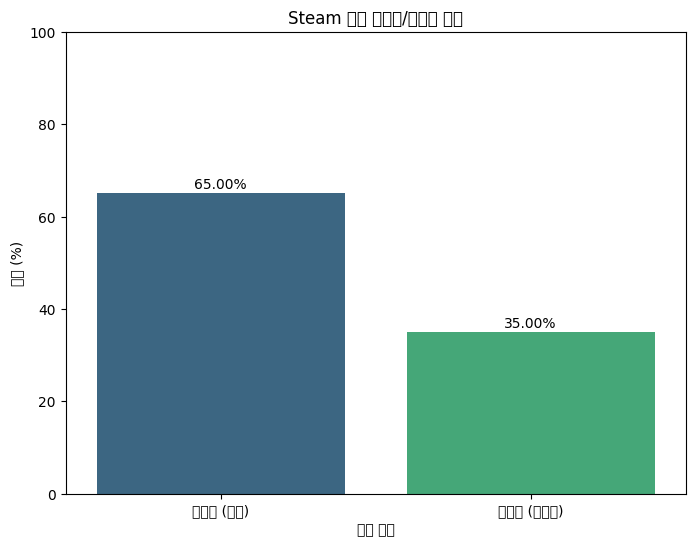


수집된 리뷰들의 긍정적/부정적 분포는 다음과 같습니다:


,proportion
voted_up,
긍정적 (추천),65.0
부정적 (비추천),35.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (런타임 재시작 후)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

# 'voted_up' 컬럼의 분포 계산
sentiment_counts = df_reviews['voted_up'].value_counts(normalize=True) * 100
sentiment_counts.index = sentiment_counts.index.map({True: '긍정적 (추천)', False: '부정적 (비추천)'})

# 막대 그래프 생성
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Steam 리뷰 긍정적/부정적 분포')
plt.xlabel('리뷰 감성')
plt.ylabel('비율 (%)')
plt.ylim(0, 100)

# 각 막대에 비율 값 표시
for index, value in enumerate(sentiment_counts.values):
    plt.text(index, value + 1, f'{value:.2f}%', color='black', ha="center")

plt.show()

print("\n수집된 리뷰들의 긍정적/부정적 분포는 다음과 같습니다:")
display(sentiment_counts)

### 리뷰 키워드 워드클라우드 시각화

리뷰 내용에서 자주 등장하는 핵심 키워드를 추출하여 워드클라우드로 시각화합니다. 이를 위해 한국어 텍스트 분석 라이브러리인 `konlpy`와 `wordcloud`를 사용합니다.

In [ ]:
# konlpy 및 wordcloud 라이브러리 설치
!pip install konlpy wordcloud

# 한글 폰트 설치 (워드클라우드에도 필요)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 런타임 재시작이 필요할 수 있습니다.
# 이 셀 실행 후 '런타임 > 런타임 다시 시작'을 클릭하고 모든 셀을 다시 실행해주세요.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 18.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/font

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48624 (\N{HANGUL SYLLABLE BYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

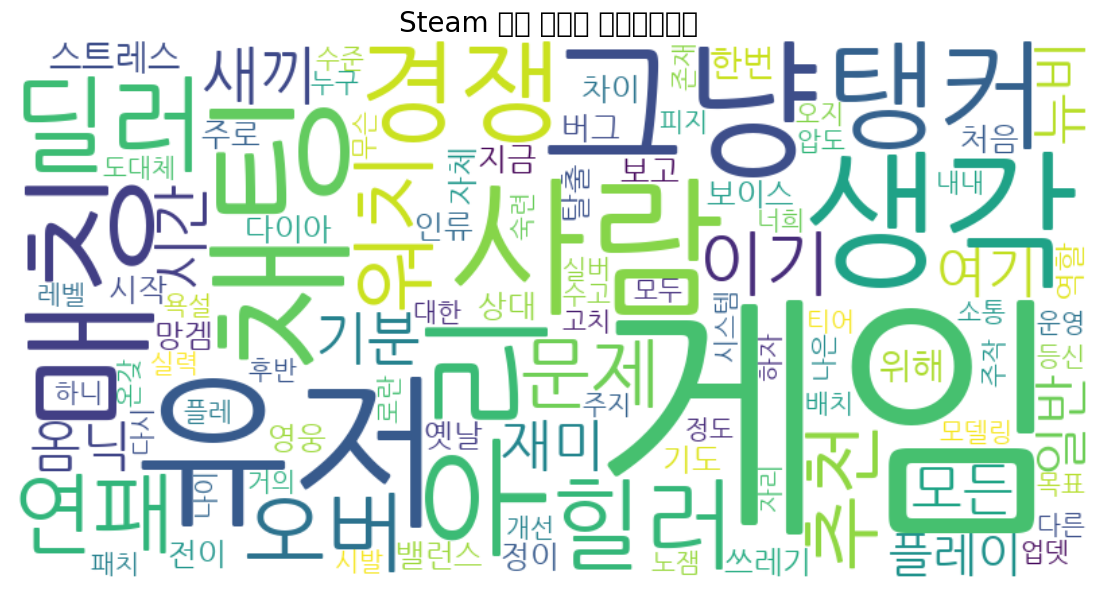

In [ ]:
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 설정 (런타임 재시작 후 정상 작동)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

okt = Okt()

# 불용어 목록 정의 (필요에 따라 추가/수정)
stop_words = set(['이', '그', '저', '것', '수', '등', '게', '또', '더', '때', '좀', '정말', '진짜', '너무', '고', '하다', '되고', '안', '있고', '같다', '싶다', '없다', '있다', '없고', '이다', '그리고', '하나', '두', '세', '네', '다섯', '여섯', '일곱', '여덟', '아홉', '열', '때문'])

# 모든 리뷰 텍스트 결합
all_reviews_text = ' '.join(df_reviews['review'].dropna().tolist())

# 명사 추출 및 불용어 제거
nouns = okt.nouns(all_reviews_text)
filtered_nouns = [n for n in nouns if n not in stop_words and len(n) > 1] # 한 글자 명사 제외

# 단어 빈도수 계산
word_counts = Counter(filtered_nouns)

# 워드클라우드 생성
# 한글 폰트 경로 설정 (설치된 나눔고딕 폰트 사용)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf' # Colab 기본 경로

wordcloud = WordCloud(font_path=font_path,
                      background_color='white',
                      width=800,
                      height=400,
                      max_words=100,
                      colormap='viridis').generate_from_frequencies(word_counts)

# 워드클라우드 표시
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Steam 리뷰 키워드 워드클라우드', fontsize=20)
plt.show()

### 그래프 한글 깨짐 문제 해결

Matplotlib에서 한글 텍스트가 올바르게 표시되지 않는 문제를 해결하기 위해, Colab 환경에 한글 폰트를 설치하고 설정합니다. 여기서는 `NanumGothic` 폰트를 사용합니다.

In [ ]:
# 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 런타임 재시작이 필요합니다.
# 이 셀 실행 후 '런타임 > 런타임 다시 시작'을 클릭하고 모든 셀을 다시 실행해주세요.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (17.5 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direct

In [ ]:
# 추천 여부 (긍정/부정) 분포 확인
print("추천 여부 (긍정/부정) 분포:")
display(df_reviews['voted_up'].value_counts(normalize=True) * 100)

# 타임스탬프 열을 읽기 쉬운 datetime 형식으로 변환
df_reviews['timestamp_created'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')
df_reviews['timestamp_updated'] = pd.to_datetime(df_reviews['timestamp_updated'], unit='s')

print("\n타임스탬프 변환 후 DataFrame (첫 5행):")
display(df_reviews[['timestamp_created', 'timestamp_updated', 'review']].head())

추천 여부 (긍정/부정) 분포:


NameError: name 'df_reviews' is not defined

In [ ]:
# 분석된 DataFrame을 CSV 파일로 저장
# index=False를 사용하여 pandas가 DataFrame 인덱스를 별도의 열로 저장하지 않도록 합니다.
output_csv_filename = 'steam_reviews_analysis.csv'
df_reviews.to_csv(output_csv_filename, index=False)
print(f"DataFrame이 '{output_csv_filename}' 파일로 저장되었습니다.")

DataFrame이 'steam_reviews_analysis.csv' 파일로 저장되었습니다.


In [ ]:
import os

if os.path.exists('steam_reviews_analysis.csv'):
    print("파일 'steam_reviews_analysis.csv'이(가) 현재 디렉토리에 있습니다.")
else:
    print("파일 'steam_reviews_analysis.csv'이(가) 현재 디렉토리에 없습니다.")

파일 'steam_reviews_analysis.csv'이(가) 현재 디렉토리에 있습니다.


In [ ]:
from google.colab import files

# 'steam_reviews_analysis.csv' 파일을 로컬로 다운로드
files.download('steam_reviews_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Google Drive가 성공적으로 마운트되면, `steam_reviews_analysis.csv` 파일을 지정된 Drive 경로로 복사합니다. 여기서는 'My Drive'의 최상위 경로에 저장하도록 하겠습니다.

In [ ]:
import shutil
import os

source_path = 'steam_reviews_analysis.csv'
destination_dir = '/content/drive/MyDrive/'

# 대상 디렉토리가 없으면 생성 (선택 사항, 보통 MyDrive는 존재)
os.makedirs(destination_dir, exist_ok=True)

# 파일을 Google Drive로 복사
shutil.copy(source_path, destination_dir)

print(f"'{source_path}' 파일이 Google Drive의 '{destination_dir}' 경로에 저장되었습니다.")

'steam_reviews_analysis.csv' 파일이 Google Drive의 '/content/drive/MyDrive/' 경로에 저장되었습니다.


# Colab 시작 페이지